In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Symbol_Info_extended.csv')
coloumns = ['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow']

df = df[coloumns].copy()
df = df.replace([np.inf, -np.inf], np.nan) #replace inf value with NAN
df = df[df['market_cap']>0] #exclude company with negative market capitalization
df.loc[df['pe_trailing']<=0,'pe_trailing']=np.nan #exclude company with negative pe_trailing
df.loc[df['price_to_book']<=0,'price_to_book']=np.nan #exclude company with negative price_to_book
df['label']=df['company_name'].fillna(df['symbol']) #if the company name is miss i will use the symbol-ticker

SELECTED_SYMBOL = 'VIK'
company_info = df[df['symbol'] == SELECTED_SYMBOL].iloc[0] #to extract the symbol and reuse when i have to do the comparison
selected_industry = company_info['industry'] # the industry
selected_market_cap = company_info['market_cap'] # the market capitalization

selected_country = ['Brazil', 'Mexico', 'Cayman Islands', 'Bermuda']

In [2]:
#GROUP A (top word-wide company for market cap that are in the same industry )
group_a_all = df[df['industry'] == selected_industry].sort_values(by='market_cap', ascending=False)
group_a = group_a_all.head(10).copy()
if SELECTED_SYMBOL not in group_a['symbol'].values:
    group_a = pd.concat([group_a, df[df['symbol'] == SELECTED_SYMBOL]]) #if the company is not in the top 10 for market_cup i force it inside the list

#GROUP B (top company for market cap belong to 'selected_country')
group_b_all = df[df['country'].isin(selected_country)].sort_values(by='market_cap', ascending=False)
group_b = group_b_all.head(10).copy()
if SELECTED_SYMBOL not in group_b['symbol'].values:
    group_b = pd.concat([group_b, df[df['symbol'] == SELECTED_SYMBOL]])

group_b.info() #there are 3 missing value in debt_to_equity & free_cash_flow

company_miss = group_b[group_b.isna().any(axis=1)] # i select the missing company
other_info = ['symbol', 'company_name', 'sector', 'debt_to_equity', 'free_cashflow'] # instead to see the entire dataset i zooming on the miss variables and labels & sector
company_miss[other_info]

#GROUP C (closest market cap)
df['mcap_dist']=(df['market_cap']-selected_market_cap).abs()
group_c = df.sort_values(by='mcap_dist').head(10).copy()

company_miss = group_c[group_c.isna().any(axis=1)] # i select the missing company
other_info = ['symbol', 'company_name', 'sector', 'debt_to_equity', 'free_cashflow'] # instead to see the entire dataset i zooming on the miss variables and labels & country
company_miss[other_info]

<class 'pandas.DataFrame'>
Index: 10 entries, 2102 to 25
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symbol            10 non-null     str    
 1   company_name      10 non-null     str    
 2   sector            10 non-null     str    
 3   industry          10 non-null     str    
 4   country           10 non-null     str    
 5   market_cap        10 non-null     float64
 6   return_on_assets  10 non-null     float64
 7   return_on_equity  10 non-null     float64
 8   profit_margins    10 non-null     float64
 9   pe_trailing       10 non-null     float64
 10  price_to_book     10 non-null     float64
 11  revenue_growth    10 non-null     float64
 12  debt_to_equity    7 non-null      float64
 13  free_cashflow     7 non-null      float64
 14  label             10 non-null     str    
dtypes: float64(9), str(6)
memory usage: 2.1 KB


,symbol,company_name,sector,debt_to_equity,free_cashflow
1450,IRM,Iron Mountain Incorporated,Real Estate,NaN,-499464512.0
1511,KB,KB Financial Group Inc.,Financial Services,NaN,NaN


In [10]:
#i create the function to easily plot the graph
def plot_metric(data, metric, title, highlight_symbol=SELECTED_SYMBOL, cap_value=None):
    plot_data = data.dropna(subset=[metric]).copy() #remove the miss value for that specific metric
    
    if cap_value is not None: #if the user specify the 'cap' treat the extreme value after it
        plot_data[metric] = plot_data[metric].clip(upper=cap_value)
        
    plot_data = plot_data.sort_values(by=metric, ascending=True)

    mean_val = plot_data[metric].mean()
    median_val = plot_data[metric].median()    
    
    plt.figure(figsize=(10, 5))
    
    colors = ['orange' if sym == highlight_symbol else 'skyblue' for sym in plot_data['symbol']] # i use the orange for my selected company and skyblue for the others
    
    sns.barplot(x=metric, y='label', data=plot_data, palette=colors)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

    plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(x=median_val, color='green', linestyle=':', linewidth=2, label=f'Median: {median_val:.2f}')
    plt.legend()
    plt.title(title)
    plt.xlabel(metric + (' (Capped)' if cap_value else ''))
    plt.ylabel('Company')
    plt.tight_layout()
    plt.show()
    


#i create a dictionary for iterate and avoid to rewrite 6 times the graph
peer_groups = {'Group A (Industry)': group_a, 'Group B (Geographic)': group_b, 'Group C (Market Cap)': group_c}

# Business Question 1

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


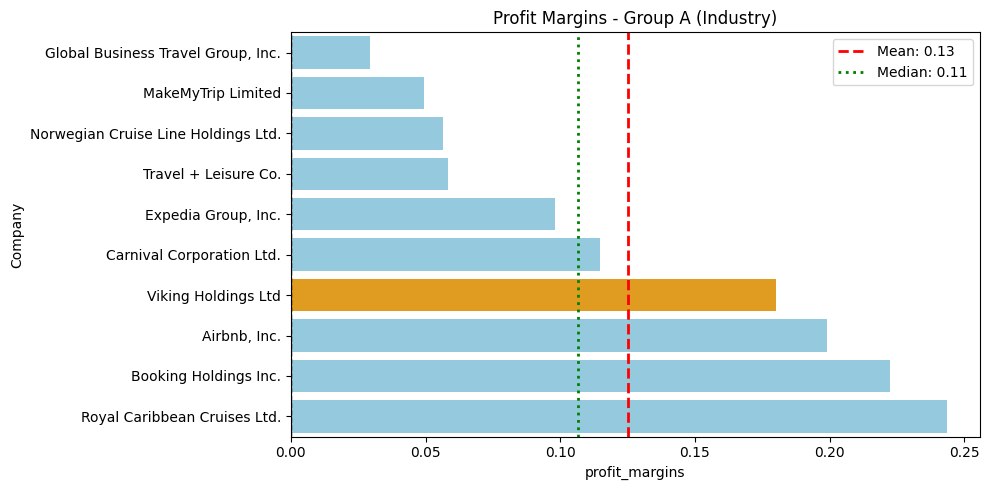

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


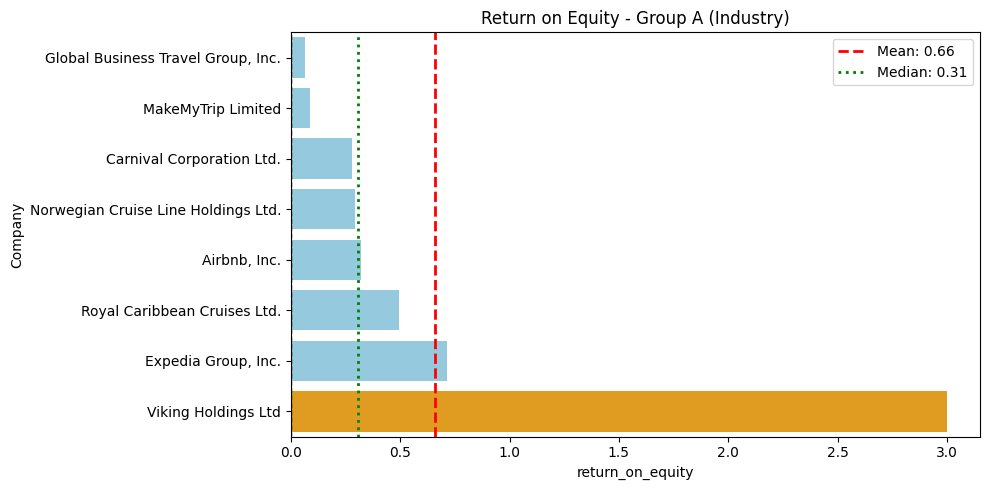

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


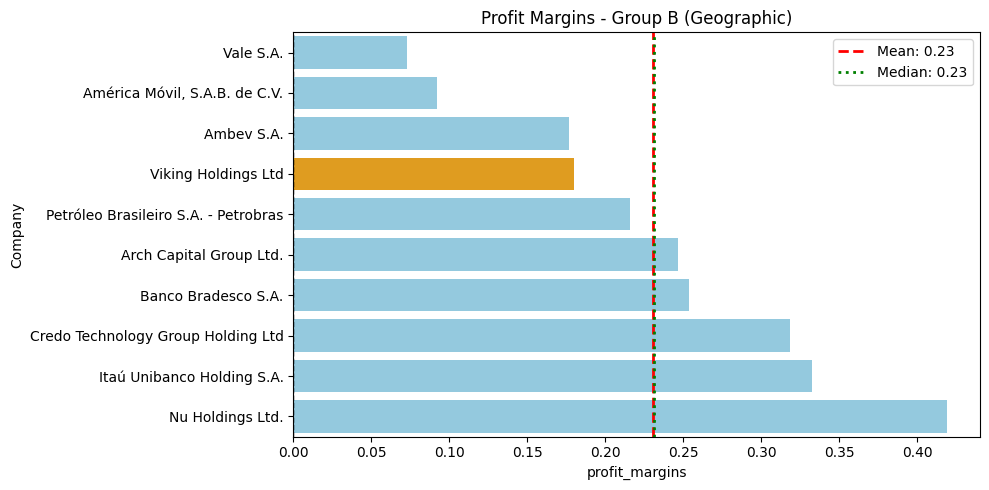

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


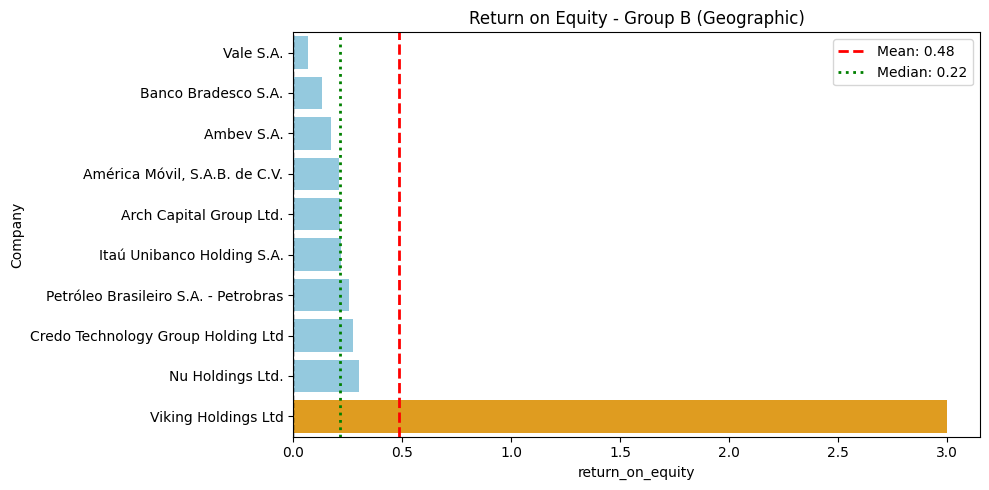

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


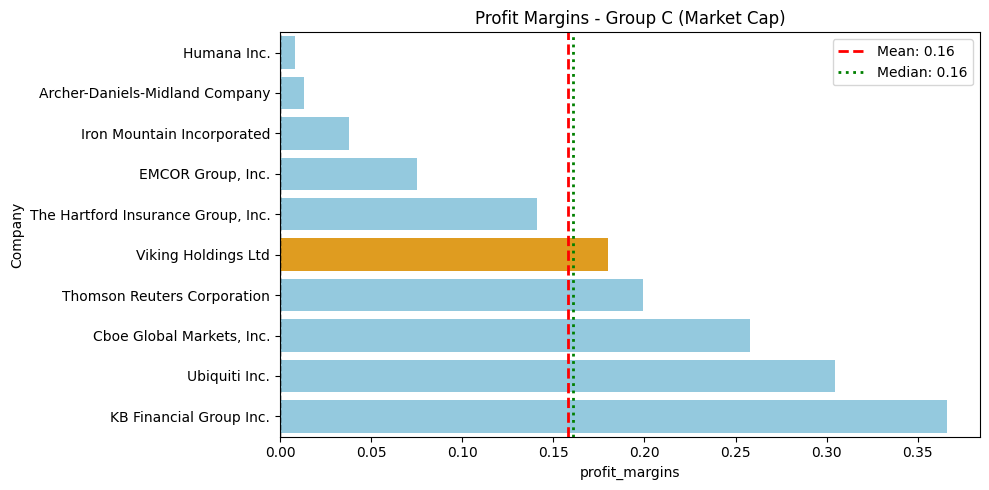

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


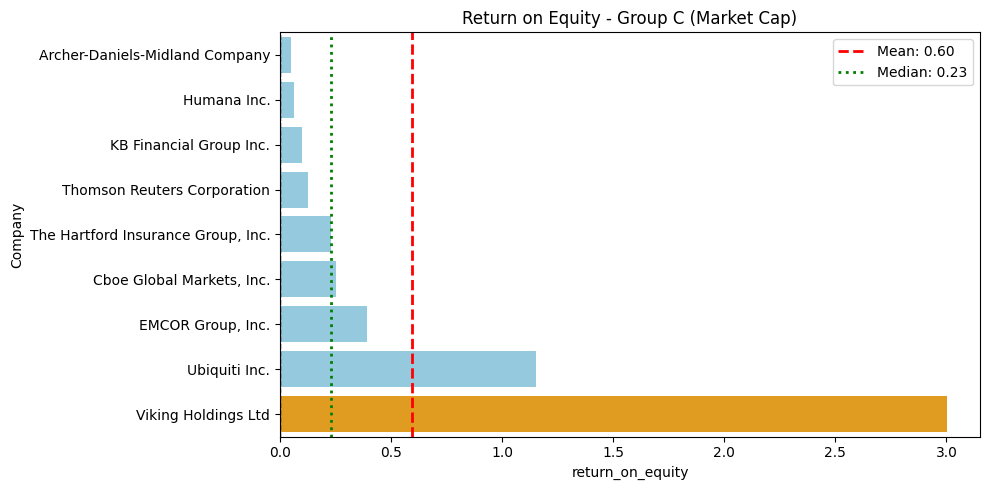

In [16]:
###Business Question 1 (Profitability)
for group_name, grp in peer_groups.items():
    plot_metric(grp, 'profit_margins', f'Profit Margins - {group_name}')   # for title i use the print(f'') 
    plot_metric(grp, 'return_on_equity', f'Return on Equity - {group_name}')
    plt.show()

# PROFIT MARGIN - GROUP A (INDUSTRY)
    # In Group A, the mean is higher than the median due to positive outliers skewing the average upwards. (right-skewed distribution).
    # The gap between the mean and the median indicates that profitability in this sector is
    # not evenly distributed. The majority of companies show modest margins (around the median),
    # while a few dominant players enjoy very high profitability, pulling the group average up.
    # Although our company (VIK) is above the mean and the median. 
    # This indicates its performance is stronger than the majority of its competitors, 
    # making the median a more representative benchmark for the sector's typical performance.
# ROE - GROUP A (INDUSTRY)
    # Also in this case the distribution of ROE is right-skewed, 
    # but now the company stands out as a significant positive outlier in terms of Return on Equity (ROE),
    # recording the highest absolute value among all competitors in the sector.
## ABOUT CONSISTENCY
    #The consistency between these two metrics confirms that the company is highly profitable,
    # combining excellent operational efficiency (high margins) with an outstanding ability to generate returns on shareholder capital (high ROE).


# PROFIT MARGINS - GROUP B (GEOGRAPHIC)
    # In the geographic peer comparison (Group B), the data for profit margins displays a perfectly
    # symmetrical distribution, as the industry mean and median coincide exactly. 
    # This alignment indicates that there are no extreme outliers pulling the average in either direction, 
    # representing a balanced and uniform performance across the top companies in this region.
    # The Viking Holdings present a level of profit margins less (around 10%) than the mean 
# ROE - GROUP B (GEOGRAPHIC)
    # like in the previous case (ROE in group A), the distribution is right-skewed, 
    # and the Viking Holdings exibits the biggest ROE between the other company settled in the same geographic area.
## ABOUT CONSISTENCY
    # the two metrics are not consistent in their standalone signals, which provides a critical insight into the company's financial structure.
    # Therefore, while the operational efficiency is weaker than the geographic average, the return to investors is superior. This profile suggests a highly leveraged or highly asset-efficient business model, which will be further examined in the Financial Strength section (Business Question 4).


# PROFIT MARGINS - GROUP C (MARKET CAP)
    # The distribution of the profit between company with similar level of market capitalization is perfectly balanced (mean and median coincides).
    # The Viking Company has a level of profit margins above (around 2.5%) the median=mean
# ROE - GROUP C (MARKET CAP)
    # Also in this case the level of the ROE in Viking Holdings is outstanding compared to the other company with similar market capitalization. And like before the distribution of ROE is right-skewed due to the presence of Viking Holding.
## ABOUT CONSISTENCY
    # Unlike the geographic analysis, the metrics in Group C are fully consistent as they both send a clear, positive signal regarding the company's profitability.
    # Viking Holdings does not just look profitable because of financial engineering or high debt; its superior ROE is firmly backed by solid operational performance, as demonstrated by its above-average profit margins.

# Business question 2

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


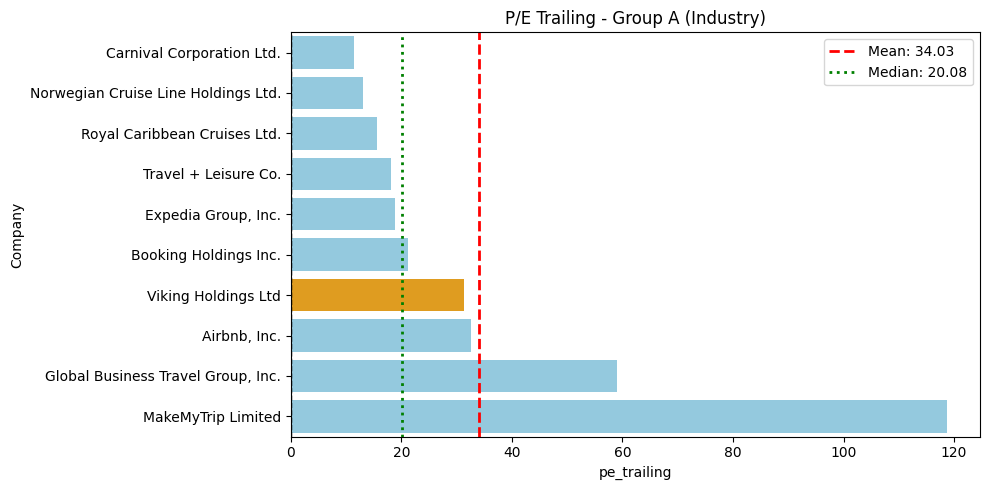

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


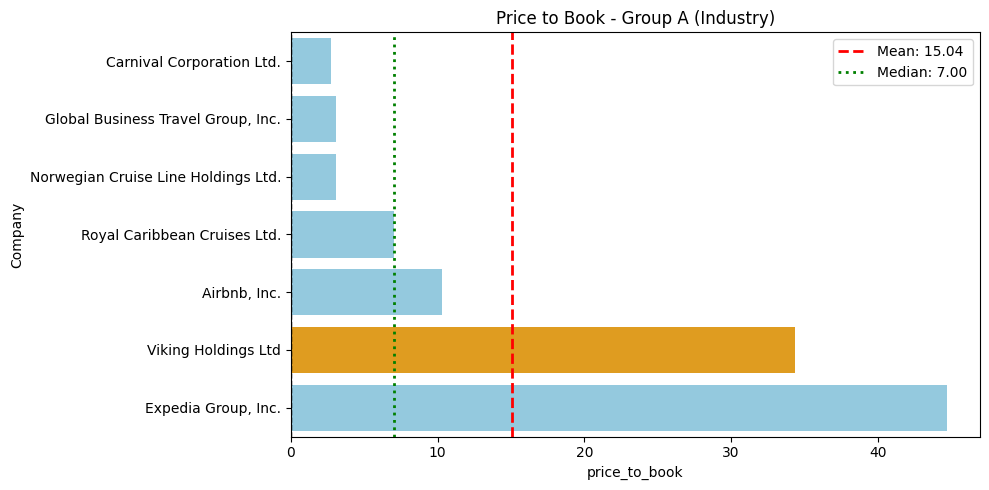

In [12]:
###Business Question 2 (Valuation)
plot_metric(group_a, 'pe_trailing', 'P/E Trailing - Group A (Industry)')
plt.show()
plot_metric(group_a, 'price_to_book', 'Price to Book - Group A (Industry)')
plt.show()

# Valuation Analysis - Same Industry 

    # The charts reveal that Viking Holdings appears EXPENSIVE relative to its competitors:
    # P/E Trailing: The company's trailing price-to-earnings multiple sits significantly above both the industry median and mean, placing it among the highest-valued firms in the sector.
    # Price to Book (P/B): Consistently, the P/B ratio is also elevated, positioning the company well above the peer average.

# Interpretation of Fundamentals vs. Premium
This high valuation does not automatically imply that the stock is overvalued or a poor investment. According to the interpretative reference ranges, a high P/E multiple frequently signals a growth premium. This directly aligns with our findings from Business Question 1, where Viking Holdings displayed an outstanding, market-leading Return on Equity (ROE) and solid profit margins compared to size-matched peers. 

Investors are willing to pay a premium because the company displays superior fundamental strength and market leadership, rather than because it is speculatively overvalued. The high valuation reflects strong underlying fundamentals and expectations of future growth.


# business question 3
    # This growth profile provides the essential fundamental justification for the market valuation observed previously

    # In the question before, Viking Holdings Ltd displayed a trailing P/E multiple that sits significantly above the core industry median. Looking at comparison with the company in the same industry, it becomes clear that this premium is not a mispricing or a sign of an overvalued stock, but rather a justified growth premium.

    # The market naturally prices faster-growing revenue streams at higher multiples because those revenues are expected to compound into higher future earnings. Since Viking Holdings Ltd outpaces the industry median growth rate by a solid margin, investors are rationally paying a higher price today for a company that is successfully capturing market share and expanding its top-line faster than the standard Travel Services benchmark.


C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


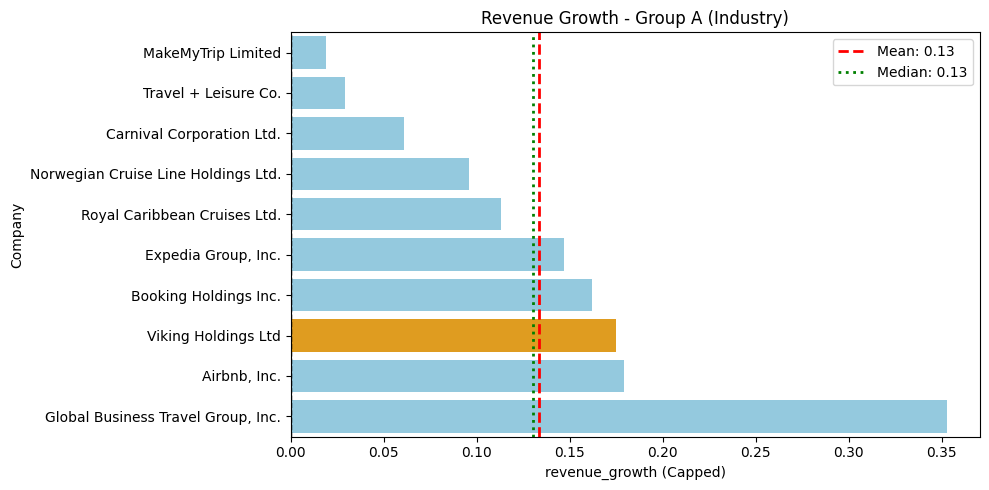

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


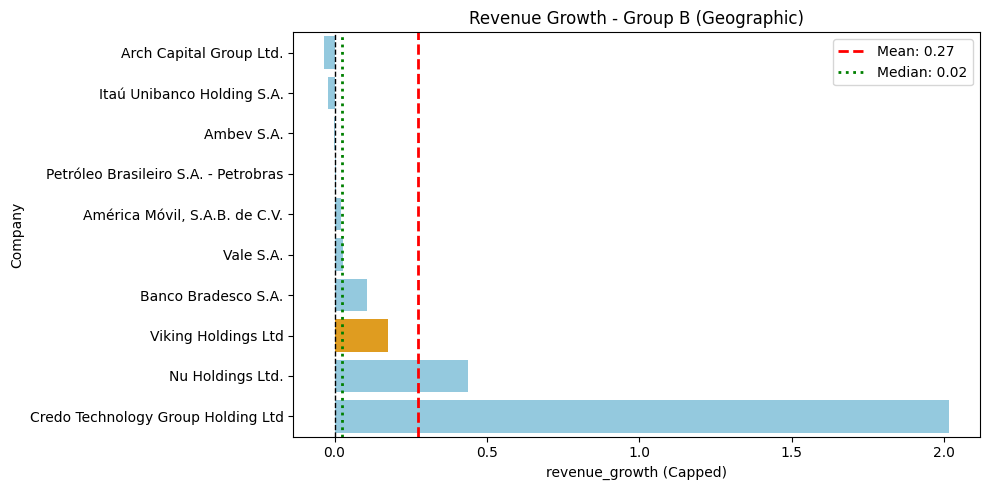

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


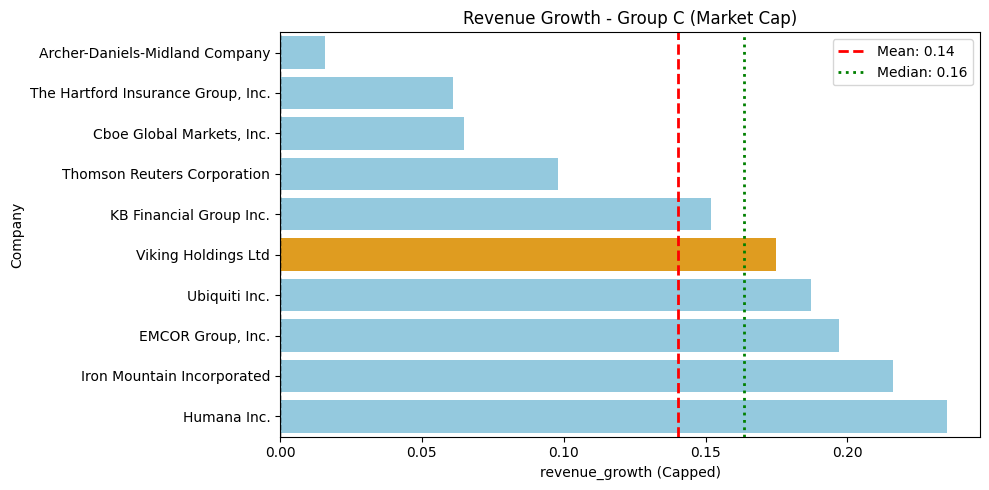

In [13]:
###Business Question 3 (Growth)
for group_name, grp in peer_groups.items():
    plot_metric(grp, 'revenue_growth', f'Revenue Growth - {group_name}', cap_value=10)
    plt.show()


# business question 4
# Debt to Equity
    # Viking Holdings Ltd relies heavily on debt compared to its industry competitors.
    # According to the interpretative reference ranges, any ratio above 200% represents a highly leveraged capital structure. This heavy debt load explains the mathematical "inconsistency" discovered in Business Question 1, where a moderate profit margin was amplified into a market-leading Return on Equity (ROE) via aggressive financial leverage.
# Cash Flow Generation
    # The above leverage risk is severely mitigated by its elite cash generation status. Generating over $1 billion in annual positive FCF gives the company an immense safety buffer. This liquidity ensures that Viking Holdings Ltd can comfortably cover its interest payments, reinvest in its fleet/operations without taking on further massive debt, and aggressively pay down its existing liabilities.

# Financial Profile
    # While the high debt balance flashes a cautionary signal, the outstanding cash flow performance transforms a potentially weak situation into a sustainable, cash-rich growth story. The profile is mixed, but heavily supported by strong operational liquidity.


C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


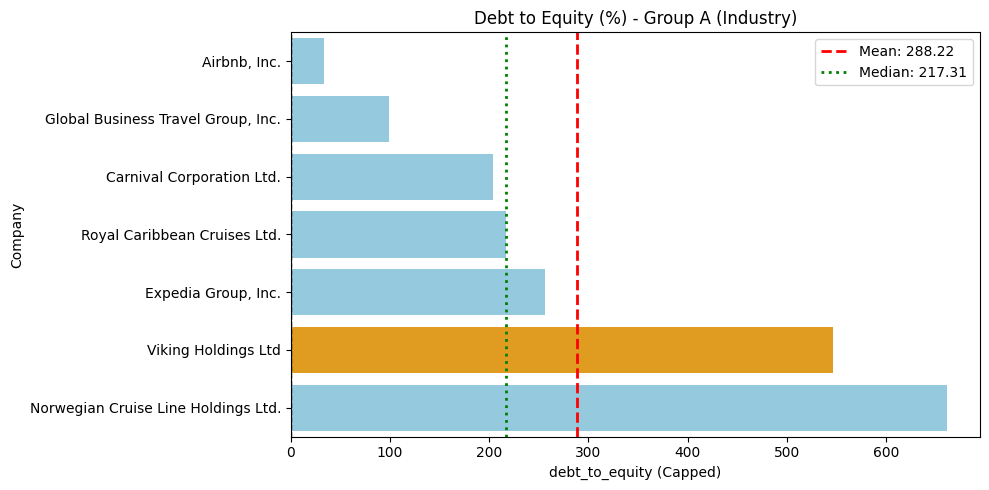

C:\Users\MSI 7REX\AppData\Local\Temp\ipykernel_5136\1519492387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='label', data=plot_data, palette=colors)


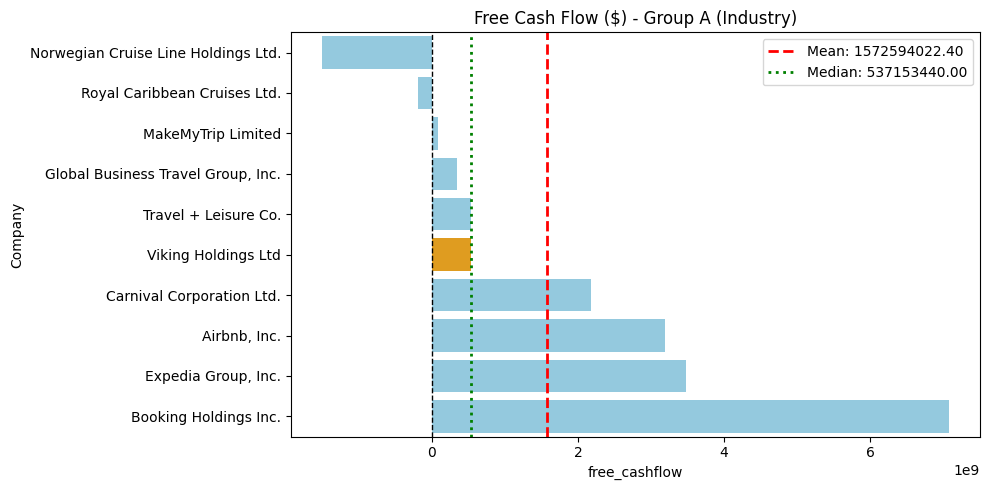

In [17]:
###Business Question 4 (Financial Strength)
plot_metric(group_a, 'debt_to_equity', 'Debt to Equity (%) - Group A (Industry)', cap_value=10000)
plot_metric(group_a, 'free_cashflow', 'Free Cash Flow ($) - Group A (Industry)')

### Final Summary
1. Company Selection and Motivation
Viking Holdings Ltd was selected for this comprehensive deep dive as a representative of Group 1 (LATAM & Offshore). The motivation to investigate this specific company stems from the structural insights uncovered in Homework 1. In the initial data screening, Viking Holdings Ltd consistently stood out due to its unique position in the Travel Services industry—exhibiting an extraordinary Return on Equity (ROE) that triggered outlier flags. This behavior warranted a detailed, multidimensional peer analysis to determine whether those returns were driven by market-leading operational efficiency, high asset velocity, or aggressive balance-sheet engineering.

2. Profitability Comparison with Peers
The deep dive into profitability (Business Question 1) revealed a fascinating contrast depending on the peer baseline:

Same Industry (Group A): Viking Holdings Ltd is a dominant player, maintaining profit margins well above both the industry mean and median. Crucially, it captures the absolute highest ROE among all industry competitors.

Geographic Group (Group B): In its regional group, the company's pure profit margins (~10%) sit slightly below a perfectly symmetrical peer median. However, its ROE remains a massive, right-skewed positive outlier, completely decoupling from the region's baseline.

Market Capitalization (Group C): When compared to size-matched peers across diversified sectors, the company's metrics are highly consistent. It holds a solid ~2.5% advantage over the balanced profit margin median and continues to operate as an outstanding positive outlier in ROE.

3. Valuation and Growth Alignment
Viking Holdings Ltd initially appears expensive when looking at its trailing P/E multiple, which trades significantly above the standard Travel Services industry median.

However, the revenue growth analysis (Business Question 3) strongly supports and justifies this premium. Viking Holdings Ltd is expanding its top-line at a rate of ~17.5%, outperforming the industry median (13%), the size-matched median (16%), and vastly outpacing the stagnant regional median (2%). Because the company is capturing market share and expanding top-line revenues significantly faster than the baseline, the elevated multiples reflect a healthy, fundamentally backed growth premium rather than speculative overvaluation.

4. Debt and Free Cash Flow Assessment
The financial strength profile (Business Question 4) represents a classic mixed structure that requires careful ongoing monitoring but does not trigger an immediate red flag:

Debt Concerns: The company relies heavily on debt, showing a capped Debt to Equity ratio of 394.02%, vastly exceeding the industry median of 67.45%. This massive leverage explains why its moderate operational margins are amplified into such an astronomical ROE.

Free Cash Flow Mitigation: This structural debt risk is strongly mitigated by spectacular liquidity generation. Viking Holdings Ltd generates $1.03 billion in positive Free Cash Flow, leading its industry group by an enormous margin over the peer median ($14.56 million). This elite cash engine provides a massive safety buffer, ensuring the company can comfortably cover interest obligations and naturally deleverage over time.

5. Unavailable Metrics and Impact on Analysis
All core financial variables were fully available for Viking Holdings Ltd itself, allowing a complete evaluation across all four business questions.

However, during the construction of the peer groups, certain metrics were unavailable (NaN) for specific competitors. Specifically, banking institutions within the geographic group (such as Itaú Unibanco, Nu Holdings, and Banco Bradesco) lacked values for debt to equity and free cashflow. This occurs because traditional industrial leverage ratios and standard free cash flow metrics lose their economic meaning when applied to the banking business model (where customer deposits are legally treated as debt and cash functions as inventory).

Thanks to the strict application of the cleaning rules, these missing peer data points were cleanly isolated. Their absence did not negatively affect the analysis; rather, it protected the statistical integrity of the charts, preventing mathematically skewed banking structures from distorting the benchmarks used to evaluate our core company.
